# 🧪 Practical Exam: Data Mining with Python — GlobalTrade Ltd.

**Course:** Data Mining  
**Format:** Hands-on (Jupyter Notebook)  
**Dataset:** `global_sales.csv`  
**Context:** บริษัท “**GlobalTrade Ltd.**” เป็นบริษัทค้าปลีกข้ามชาติที่จำหน่ายสินค้าหลากหลายประเภททั่วโลก ต้องการใช้ Data Mining เพื่อวิเคราะห์ยอดขายและผลกำไร เพื่อปรับกลยุทธ์การขายให้เหมาะสมกับแต่ละภูมิภาคและช่องทางการขาย

**Schema (columns):**  
`Region, Country, Item Type, Sales Channel, Order Priority, Order Date, Order ID, Ship Date, Units Sold, Unit Price, Unit Cost, Total Revenue, Total Cost, Total Profit`

> 🔒 **ข้อกำหนดการทำข้อสอบ**: ห้ามลบเซลล์ข้อสอบ แต่สามารถเพิ่มเซลล์ใหม่ใต้แต่ละข้อเพื่อแสดงการทำงานเพิ่มเติม  
> 📝 **รูปแบบคำตอบ**: แบบเติมคำ (fill-in) ในส่วน `____` และ/หรือเพิ่มโค้ดของคุณเอง


## คำแนะนำโดยรวม
- รันเซลล์ตามลำดับจากบนลงล่าง
- ถ้าเห็น `____` ให้เติมคำสั่ง/พารามิเตอร์ให้ถูกต้อง
- เมื่อเสร็จสิ้นในแต่ละตอน ให้รันเพื่อตรวจว่าไม่มี error
- เซฟไฟล์เป็น: `dm_exam_รหัสนักศึกษา.ipynb` ก่อนส่ง  `sitthikorn.m@rmutsb.ac.th`

---


---
## ตอนที่ 1: การนำเข้าไลบรารี (5 คะแนน)

**โจทย์:** นำเข้าไลบรารีสำหรับงาน Data Mining ได้แก่ `pandas`, `numpy`, `matplotlib`, `seaborn`, และโมดูลจาก `sklearn`

> เติมคำสั่งในช่องว่างให้ถูกต้อง


In [9]:
# เติมคำสั่งให้ครบ/ถูกต้อง
#mport ______ as pd
# import ______ as np
# import matplotlib.____ as plt
# import ______ as sns

# from sklearn.model_selection import ______
# from sklearn.linear_model import ______
# from sklearn.neighbors import ______

# # แสดงกราฟในโน้ตบุ๊ก
# %matplotlib inline


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline

---
## ตอนที่ 2: การนำเข้าข้อมูล (5 คะแนน)

**โจทย์:** อ่านไฟล์ `global_sales.csv` เป็นตัวแปร `df` และแสดงข้อมูล 5 แถวแรก

> เติมคำสั่งให้ถูกต้อง


In [11]:
# เติมคำสั่งให้ถูกต้อง
# df = pd.______('global_sales.csv')
# df.______()  # แสดง 5 แถวแรก


In [12]:
# เติมคำสั่งให้ถูกต้อง
df = pd.read_csv('./datasets/Sales_Records.csv')
df.head() # แสดง 5 แถวแรก

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Sub-Saharan Africa,South Africa,Fruits,Offline,M,7/27/2012,443368995,7/28/2012,1593,9.33,6.92,14862.69,11023.56,3839.13
1,Middle East and North Africa,Morocco,Clothes,Online,M,9/14/2013,667593514,10/19/2013,4611,109.28,35.84,503890.08,165258.24,338631.84
2,Australia and Oceania,Papua New Guinea,Meat,Offline,M,5/15/2015,940995585,6/4/2015,360,421.89,364.69,151880.40,131288.40,20592.00
3,Sub-Saharan Africa,Djibouti,Clothes,Offline,H,5/17/2017,880811536,7/2/2017,562,109.28,35.84,61415.36,20142.08,41273.28
4,Europe,Slovakia,Beverages,Offline,L,10/26/2016,174590194,12/4/2016,3973,47.45,31.79,188518.85,126301.67,62217.18


---
## ตอนที่ 3: สำรวจข้อมูลเบื้องต้น (EDA) (10 คะแนน)

**โจทย์:**  
1) แสดงขนาดของข้อมูล (จำนวนแถว, คอลัมน์)  
2) ตรวจสอบค่าว่างในแต่ละคอลัมน์  
3) แสดงค่าสถิติของ `Total Profit` (เช่น mean, std)


In [14]:
# # 1) ขนาดของข้อมูล
# df.______

# # 2) ค่าว่าง
# df.______( )

# # 3) ค่าสถิติของ Total Profit
# df['Total Profit'].______()



# 1) ขนาดของข้อมูล
df.shape

# 2) ค่าว่าง
df.isnull().sum()

# 3) ค่าสถิติของ Total Profit
df['Total Profit'].describe()

count    1.500000e+06
mean     3.923999e+05
std      3.789181e+05
min      2.410000e+00
25%      9.506640e+04
50%      2.813704e+05
75%      5.654252e+05
max      1.738700e+06
Name: Total Profit, dtype: float64

---
## ตอนที่ 4: แผนภาพการกระจาย (Scatter Plot) (10 คะแนน)

**โจทย์:** สร้างกราฟ scatter แสดงความสัมพันธ์ระหว่าง `Unit Cost` (แกน x) และ `Total Profit` (แกน y) โดยใช้ **matplotlib** พร้อมตั้งชื่อกราฟและชื่อแกน


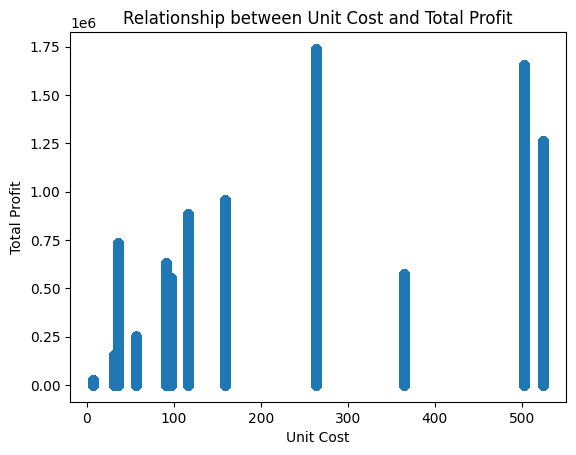

In [15]:
# # เติมพารามิเตอร์ให้ถูกต้อง
# plt.figure()
# plt.scatter(df['_____'], df['_____'])
# plt.title('Relationship between Unit Cost and Total Profit')
# plt.xlabel('Unit Cost')
# plt.ylabel('Total Profit')
# plt.show()


# เติมพารามิเตอร์ให้ถูกต้อง
plt.figure()
plt.scatter(df['Unit Cost'], df['Total Profit'])
plt.title('Relationship between Unit Cost and Total Profit')
plt.xlabel('Unit Cost')
plt.ylabel('Total Profit')
plt.show()

---
## ตอนที่ 5: โมเดล Linear Regression เพื่อทำนายกำไรรวม (20 คะแนน)

**โจทย์:**  
- ใช้ตัวแปรอิสระ `Units Sold`, `Unit Price`, `Unit Cost` เพื่อทำนาย `Total Profit`  
- แบ่งข้อมูล train:test = 80:20 (กำหนด `random_state=42`)  
- สร้างและฝึกโมเดล `LinearRegression`


In [16]:
# # เตรียมข้อมูล
# X = df[['Units Sold', 'Unit Price', 'Unit Cost']]
# y = df['Total Profit']

# # แบ่งข้อมูล
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=____, random_state=42)

# # สร้างและฝึกโมเดล
# model = LinearRegression()
# model.____(____, ____)

# # แสดงค่าสัมประสิทธิ์และจุดตัดแกน
# print('Coefficients:', model.coef_)
# print('Intercept:', model.intercept_)


# เตรียมข้อมูล
X = df[['Units Sold', 'Unit Price', 'Unit Cost']]
y = df['Total Profit']

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# สร้างและฝึกโมเดล
model = LinearRegression()
model.fit(X_train, y_train)

# แสดงค่าสัมประสิทธิ์และจุดตัดแกน
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

Coefficients: [   78.46847618  4998.41620998 -4997.25463809]
Intercept: -392575.35148819763


---
## ตอนที่ 6: โมเดล K-Nearest Neighbors (KNN) จำแนกช่องทางการขาย (20 คะแนน)

**โจทย์:**  
- ใช้คุณลักษณะ `Units Sold`, `Unit Price`, `Total Profit` เพื่อจำแนก `Sales Channel` (Online/Offline)  
- แบ่งข้อมูล train:test = 80:20 (`random_state=42`)  
- ใช้ `KNeighborsClassifier(n_neighbors=5)` และฝึกโมเดล


In [18]:
# # เตรียมข้อมูลสำหรับ KNN
# X = df[['Units Sold', 'Unit Price', 'Total Profit']]
# y = df['Sales Channel']

# # แบ่งข้อมูล
# X_train, X_test, y_train, y_test = train_test_split(____, ____, test_size=0.2, random_state=42)

# # โมเดล KNN
# knn = KNeighborsClassifier(n_neighbors=5)
# knn.____(____, ____)


# เตรียมข้อมูลสำหรับ KNN
X = df[['Units Sold', 'Unit Price', 'Total Profit']]
y = df['Sales Channel']

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# โมเดล KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


---
## ตอนที่ 7: การประเมินโมเดล (20 คะแนน)

**โจทย์:**  
- คำนวณค่า **R²** ของโมเดล Linear Regression  
- คำนวณ **Accuracy** ของโมเดล KNN


In [20]:
# from sklearn.metrics import r2_score, accuracy_score

# # Linear Regression
# y_pred_lr = model.predict(X_test)
# r2 = r2_score(____, ____)
# print('R² =', r2)

# # KNN
# y_pred_knn = knn.predict(X_test)
# acc = accuracy_score(____, ____)
# print('Accuracy =', acc)


from sklearn.metrics import r2_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

# -----------------------
# 🔹 Linear Regression
# -----------------------

# เตรียมข้อมูลสำหรับ Linear Regression
X_lr = df[['Units Sold', 'Unit Price', 'Unit Cost']]
y_lr = df['Total Profit']

# แบ่งข้อมูล train:test = 80:20
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

# สร้างและฝึกโมเดล
model_lr = LinearRegression()
model_lr.fit(X_train_lr, y_train_lr)

# พยากรณ์และคำนวณค่า R²
y_pred_lr = model_lr.predict(X_test_lr)
r2 = r2_score(y_test_lr, y_pred_lr)
print('R² (Linear Regression) =', round(r2, 4))

# -----------------------
# 🔹 KNN Classification
# -----------------------

# เตรียมข้อมูลสำหรับ KNN
X_knn = df[['Units Sold', 'Unit Price', 'Total Profit']]
y_knn = df['Sales Channel']

# แบ่งข้อมูล train:test = 80:20
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

# สร้างและฝึกโมเดล KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train_knn)

# พยากรณ์และคำนวณค่า Accuracy
y_pred_knn = knn.predict(X_test_knn)
acc = accuracy_score(y_test_knn, y_pred_knn)
print('Accuracy (KNN) =', round(acc, 4))

R² (Linear Regression) = 0.8391
Accuracy (KNN) = 0.4767


---
## ตอนที่ 8: วิเคราะห์ผลเชิงธุรกิจ (10 คะแนน)

**ให้ตอบเป็น Markdown ใต้เซลล์นี้:**  
1) ตัวแปรใดส่งผลต่อกำไร (`Total Profit`) มากที่สุด ตามค่าสัมประสิทธิ์จาก Linear Regression? อธิบายเหตุผลที่เป็นไปได้  
2) โมเดล KNN ที่ใช้คุณลักษณะปัจจุบันสามารถจำแนก `Sales Channel` ได้ดีหรือไม่? มีข้อจำกัด/แนวทางปรับปรุงอะไรบ้าง (เช่น การทำ scaling, การเลือก k, การเพิ่มฟีเจอร์)


###ตัวแปรที่ส่งผลต่อ Total Profit มากที่สุด คือ Unit Price นื่องจากมีค่าสัมประสิทธิ์ (Coefficient: model.coef_) สูงที่สุด 
###โมเดล KNN มีค่า Accuracy คือ ค่า Accuracy] ซึ่งหากค่า Accuracy ต่ำกว่า 0.7 ถือว่ายังไม่ดีพอ ในการจำแนก Sales Channel (Online/Offline)

### คำตอบของนักศึกษา
(พิมพ์คำตอบของคุณที่นี่ `Double click`)


---
## (เพิ่มคะแนนพิเศษ) การปรับปรุงโมเดล (สูงสุด 10 คะแนน)

ทำอย่างน้อย 1 ข้อ:
- สร้างฟีเจอร์ใหม่ เช่น `Profit Margin = Total Profit / Total Revenue` หรือดึง `Year` จาก `Order Date` แล้วนำไปใช้ในโมเดล/สร้างกราฟ  
- ทดลองปรับ `n_neighbors` ของ KNN และทำกราฟ Accuracy ต่อค่า k  
- ทำ **Standardization** ให้กับฟีเจอร์ก่อนเทรน KNN และเปรียบเทียบผล


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
# สมมติว่า X_train, X_test, y_train, y_test ได้จากการแบ่งข้อมูลแล้ว

# สร้าง Scaler object
scaler = StandardScaler()

# Fit scaler กับ X_train และ Transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test โดยใช้ค่าสถิติจาก X_train
X_test_scaled = scaler.transform(X_test)

# แปลงกลับเป็น DataFrame เพื่อให้จัดการง่าย (เป็นทางเลือก)
# X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
# X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# สร้างโมเดล KNN ใหม่
knn_scaled = KNeighborsClassifier(n_neighbors=5)

# ฝึกโมเดลด้วยข้อมูลที่ทำ Scaling แล้ว
knn_scaled.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


---
**Prepared for:** Data Mining Practical Exam — GlobalTrade Ltd.  
**Generated:** 2025-10-30 11:41:55
